# MMSL regression at South Beach

Use the first `N_PCS` **annual DWT PCs from `MMSL_regression.ipynb`** and GESLA South Beach 9435380 sea level. Repeat each PC from January through December of its calendar year.

Following the model in `02_TIDES_MMSL_Regression.ipynb`, remove a linear trend from the valid hourly sea level and calculate monthly mean residuals (MMSLA). These are anomalies relative to the fitted trend, **retaining the seasonal cycle**; no calendar-month climatology or three-year running mean is subtracted. Monthly coverage filtering is controlled by `MIN_MONTHLY_COVERAGE`. The reference's extra three-year running-mean removal is not applied here.

Fit `(1 + 2 × N_HARMONICS) × (N_PCS + 1)` coefficients: a mean and linear effects for each PC, plus `N_HARMONICS` sine/cosine pairs whose amplitudes depend on those PCs. The model is linear in its coefficients, so linear least squares solves the supplied `modelfun` exactly without an iterative optimizer. Reserve the latest 10% of shared calendar years for validation, with a one-month gap. Fit both the sea-level trend and regression coefficients using only the earlier fitting period; apply them unchanged to validation. The DWT PCA basis remains the one fitted over 1979–2025, so this tests held-out sea-level targets with a fixed full-record atmospheric basis, not a fully independent forecasting pipeline.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "toolkit/regression/utils/mmsl.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from toolkit.regression.utils.mmsl import monthly_sea_level, harmonic_design, modelfun, fit_mmsl

sea_level_path = repo_root / "toolkit/data/outputs/GESLA_South_Beach_9435380_NOAA.nc"

# # Option: download the GESLA South Beach record from the GeoOcean THREDDS server
# # into toolkit/data/outputs (skipped if it already exists).
# # --no-check-certificate: the GeoOcean server certificate expired on 2026-10-01.
# sea_level_url = "https://geoocean.unican.es/thredds/fileServer/rawData/GEOOCEAN/BlueMath_Course_Corvallis/GESLA_South_Beach_9435380_NOAA.nc"
# sea_level_path.parent.mkdir(parents=True, exist_ok=True)
# !wget -nc -q --show-progress --no-check-certificate -P "{sea_level_path.parent}" "{sea_level_url}"

if not sea_level_path.exists():
    raise FileNotFoundError(
        f"{sea_level_path} not found. Uncomment the THREDDS option above to download it."
    )
pc_path = repo_root / "toolkit/regression/outputs/annual_dwt_pcs.nc"
N_PCS = 5  # Choose 1 to the number of PCs exported by MMSL_regression.ipynb.
N_HARMONICS = 2  # 0: mean + PCs only; 1: annual; 2: annual + semiannual; etc.
MIN_MONTHLY_COVERAGE = 0
TEST_FRACTION_YEARS = 0.10
GAP_MONTHS = 1
colors = {"fit": "#29ABAF", "validation": "#DF826B"}
with xr.open_dataset(pc_path) as saved_pcs:
    pcs = saved_pcs.PCs.load()
if not isinstance(N_PCS, int) or isinstance(N_PCS, bool) or not 1 <= N_PCS <= pcs.sizes["n_component"]:
    raise ValueError(f"N_PCS must be an integer between 1 and {pcs.sizes['n_component']}.")
pc_columns = [f"PC{i + 1}" for i in range(N_PCS)]
annual_pcs = pd.DataFrame(pcs.isel(n_component=slice(0, N_PCS)).values,
                         index=pcs.year.values, columns=pc_columns)
annual_pcs.index.name = "year"
monthly, trend_info = monthly_sea_level(
    sea_level_path, int(annual_pcs.index.min()), int(annual_pcs.index.max()),
    minimum_coverage=MIN_MONTHLY_COVERAGE,
)
# Select the temporal split from valid overlapping monthly coverage.
common = monthly.index[monthly.mmsla_m.notna() & monthly.index.year.isin(annual_pcs.dropna().index)]
shared_years = np.sort(common.year.unique())
if len(shared_years) < 2 or not 0 < TEST_FRACTION_YEARS < 1:
    raise ValueError("Need at least two shared years and a validation fraction in (0, 1).")
n_validation_years = min(len(shared_years) - 1, max(1, int(np.ceil(len(shared_years) * TEST_FRACTION_YEARS))))
VALIDATION_START = pd.Timestamp(year=int(shared_years[-n_validation_years]), month=1, day=1)
FIT_END_EXCLUSIVE = VALIDATION_START - pd.DateOffset(months=GAP_MONTHS)
# Recalculate the target using a trend estimated exclusively before the gap.
monthly, trend_info = monthly_sea_level(
    sea_level_path, int(annual_pcs.index.min()), int(annual_pcs.index.max()),
    minimum_coverage=MIN_MONTHLY_COVERAGE, trend_fit_before=FIT_END_EXCLUSIVE,
)
print(f"Training-only linear trend: {trend_info['slope_m_per_year'] * 1000:.2f} mm/year")
print(f"Fit before {FIT_END_EXCLUSIVE.date()}; validation from {VALIDATION_START.date()}")


GESLA_South_Beach_9 100%[===================>]   8.95M  6.24MB/s    in 1.4s    
Training-only linear trend: 1.87 mm/year
Fit before 2020-12-01; validation from 2021-01-01


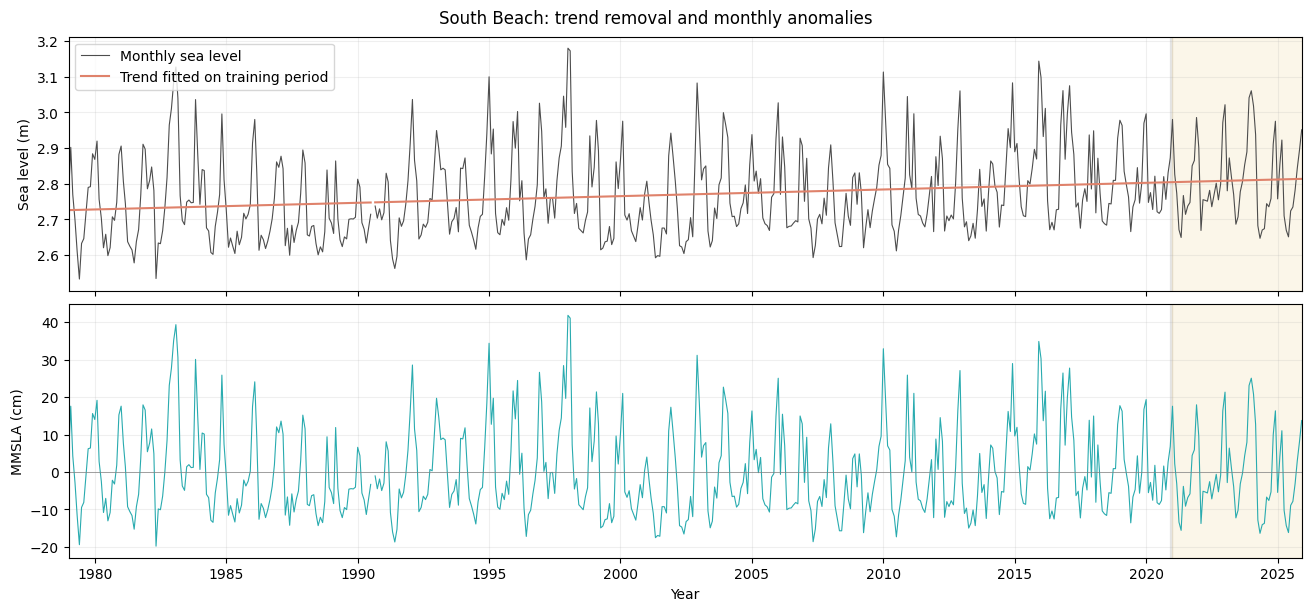

In [4]:
fig_preprocessing, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, layout="constrained")
axes[0].plot(monthly.index, monthly.sea_level_m, color="0.3", linewidth=0.8, label="Monthly sea level")
axes[0].plot(monthly.index, monthly.trend_m, color=colors["validation"], label="Trend fitted on training period")
axes[0].set_ylabel("Sea level (m)")
axes[0].legend()
axes[1].plot(monthly.index, monthly.mmsla_m * 100, color=colors["fit"], linewidth=0.8)
axes[1].axhline(0, color="0.5", linewidth=0.5)
axes[1].set_ylabel("MMSLA (cm)")
axes[1].set_xlabel("Year")
for ax in axes:
    ax.axvspan(FIT_END_EXCLUSIVE, VALIDATION_START, color="0.5", alpha=0.15)
    ax.axvspan(VALIDATION_START, monthly.index.max(), color="#E5C56C", alpha=0.15)
    ax.grid(alpha=0.2)
    ax.set_xlim(monthly.index.min(), monthly.index.max())
fig_preprocessing.suptitle("South Beach: trend removal and monthly anomalies")
plt.show()


## Linear PC-dependent harmonic model

$$\widehat{y}(t)=B(t)+\sum_{k=1}^{N_{HARMONICS}}[C_k(t)\cos(2\pi kt)+S_k(t)\sin(2\pi kt)].$$

Each amplitude is a linear combination of `[1, PC1, ..., PC_N_PCS]`, with independent coefficients for each block. The model has `(1 + 2 * N_HARMONICS) * (N_PCS + 1)` coefficients, fitted by linear least squares.

`N_HARMONICS = 0` keeps only the mean and PC effects; 1 adds the annual cycle and 2 adds the semiannual cycle. Coefficient blocks are mean, cosine 1, sine 1, cosine 2, sine 2, etc. Rank-deficient designs are rejected.

### Expanded equation for 5 PCs and 2 harmonics

$$
\begin{aligned}
\widehat{\mathrm{MMSLA}}(t) ={}& a_0+a_1PC_1+a_2PC_2+a_3PC_3+a_4PC_4+a_5PC_5\\[4pt]
&+(b_0+b_1PC_1+b_2PC_2+b_3PC_3+b_4PC_4+b_5PC_5)\cos(2\pi t)\\[4pt]
&+(c_0+c_1PC_1+c_2PC_2+c_3PC_3+c_4PC_4+c_5PC_5)\sin(2\pi t)\\[4pt]
&+(d_0+d_1PC_1+d_2PC_2+d_3PC_3+d_4PC_4+d_5PC_5)\cos(4\pi t)\\[4pt]
&+(e_0+e_1PC_1+e_2PC_2+e_3PC_3+e_4PC_4+e_5PC_5)\sin(4\pi t).
\end{aligned}
$$

Here, $t$ is the fraction of the calendar year at the start of each month. Each $PC_i$ is the current year's annual PC score, repeated from January through December. The $2\pi t$ terms describe the annual cycle and the $4\pi t$ terms the semiannual cycle. The target is monthly sea level after removal of the training-period linear trend, in metres.

There are **30 fitted coefficients**: 6 in each of the five blocks. The coefficient table below follows this same block and term order.


In [5]:
regression, model_coefficients, fit_metrics = fit_mmsl(monthly, annual_pcs, fit_before=FIT_END_EXCLUSIVE, n_harmonics=N_HARMONICS)
basis_columns = ["Intercept", *pc_columns]
coefficient_table = pd.DataFrame(model_coefficients.reshape(1 + 2 * N_HARMONICS, len(basis_columns)),
    index=["Mean"] + [f"Harmonic {k} {kind}" for k in range(1, N_HARMONICS + 1) for kind in ["cosine", "sine"]],
    columns=basis_columns)
display(coefficient_table)
regression["split"] = np.where(regression.index < FIT_END_EXCLUSIVE, "fit",
                               np.where(regression.index >= VALIDATION_START, "validation", "gap"))
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
metric_rows = []
for subset in ["fit", "validation"]:
    block = regression.loc[regression.split == subset]
    if len(block) < 2:
        raise ValueError(f"Insufficient months in {subset}.")
    metric_rows.append({"split": subset, "months": len(block),
        "start": block.index.min(), "end": block.index.max(),
        "RMSE_cm": np.sqrt(mean_squared_error(block.mmsla_m, block.fitted_m)) * 100,
        "MAE_cm": mean_absolute_error(block.mmsla_m, block.fitted_m) * 100,
        "bias_cm": (block.fitted_m - block.mmsla_m).mean() * 100,
        "R2": r2_score(block.mmsla_m, block.fitted_m)})
metrics = pd.DataFrame(metric_rows).set_index("split")
display(metrics.round(3))
np.testing.assert_allclose(
    modelfun(model_coefficients, regression.t,
             *[regression[col] for col in pc_columns], y=regression.mmsla_m, n_harmonics=N_HARMONICS),
    -regression.residual_m, atol=1e-12,
)



,Intercept,PC1,PC2,PC3,PC4,PC5
Mean,-0.002600,-0.001093,-0.008910,-0.004037,-0.000745,0.000587
Harmonic 1 cosine,0.114379,0.002165,-0.008184,-0.004032,-0.002359,0.002528
Harmonic 1 sine,-0.019409,0.002013,-0.001908,0.002020,-0.002967,0.002110
Harmonic 2 cosine,0.018398,0.000661,-0.001861,-0.001266,-0.001424,-0.001986
Harmonic 2 sine,0.007247,0.000192,-0.000132,-0.000831,-0.002808,0.001538


,months,start,end,RMSE_cm,MAE_cm,bias_cm,R2
split,,,,,,,
fit,502,1979-01-01,2020-11-01,7.079,5.326,0.00,0.635
validation,60,2021-01-01,2025-12-01,6.945,5.573,-2.02,0.594


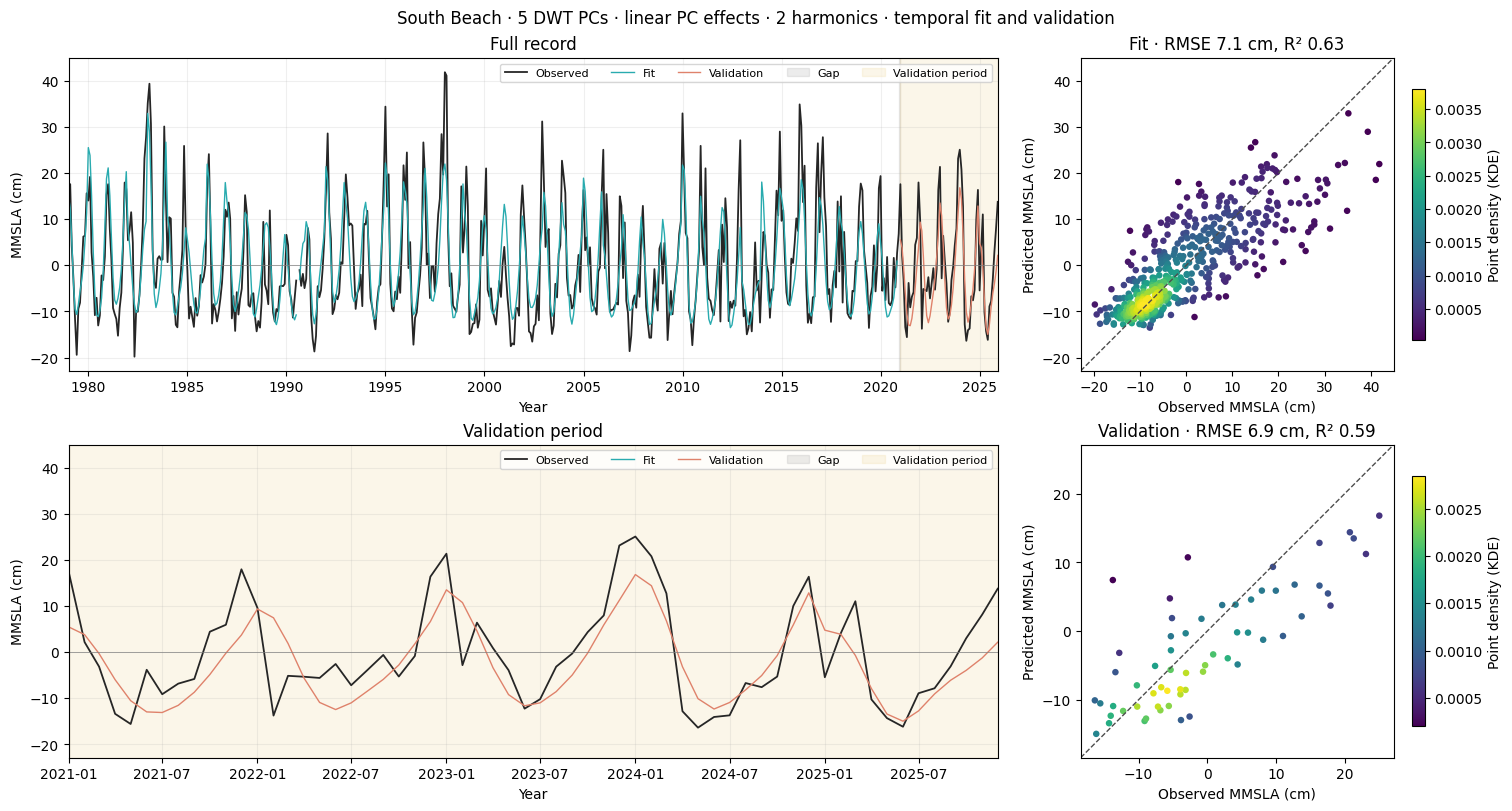

In [6]:
from scipy.stats import gaussian_kde

fig_mmsl, axes = plt.subplots(2, 2, figsize=(15, 8), layout="constrained",
                              gridspec_kw={"width_ratios": [3, 1.2]})
plot_data = regression.reindex(monthly.index)
for row, subset in enumerate(["fit", "validation"]):
    ax_time, ax_scatter = axes[row]
    ax_time.plot(plot_data.index, plot_data.mmsla_m * 100, color="0.15", linewidth=1.3, label="Observed")
    for name in ["fit", "validation"]:
        ax_time.plot(plot_data.index, plot_data.fitted_m.where(plot_data.split == name) * 100,
                     color=colors[name], linewidth=1, label=name.capitalize())
    ax_time.axvspan(FIT_END_EXCLUSIVE, VALIDATION_START, color="0.5", alpha=0.15, label="Gap")
    ax_time.axvspan(VALIDATION_START, regression.index.max(), color="#E5C56C", alpha=0.15, label="Validation period")
    ax_time.axhline(0, color="0.5", linewidth=0.5)
    ax_time.set(ylabel="MMSLA (cm)", xlabel="Year",
                xlim=(regression.index.min() if row == 0 else VALIDATION_START, regression.index.max()),
                title="Full record" if row == 0 else "Validation period")
    ax_time.legend(ncol=5, fontsize=8)
    ax_time.grid(alpha=0.2)
    block = regression.loc[regression.split == subset]
    observed, predicted = block.mmsla_m.to_numpy() * 100, block.fitted_m.to_numpy() * 100
    xy = np.vstack([observed, predicted])
    density = gaussian_kde(xy)(xy)
    order = np.argsort(density)
    scatter = ax_scatter.scatter(observed[order], predicted[order], c=density[order],
                                  cmap="viridis", s=22, edgecolors="none", rasterized=True)
    combined = np.concatenate([observed, predicted])
    margin = 0.05 * np.ptp(combined)
    limits = (combined.min() - margin, combined.max() + margin)
    ax_scatter.plot(limits, limits, color="0.3", linestyle="--", linewidth=1)
    score = metrics.loc[subset]
    ax_scatter.set(xlim=limits, ylim=limits, xlabel="Observed MMSLA (cm)", ylabel="Predicted MMSLA (cm)",
                   title=f"{subset.capitalize()} · RMSE {score.RMSE_cm:.1f} cm, R² {score.R2:.2f}")
    ax_scatter.set_aspect("equal", adjustable="box")
    fig_mmsl.colorbar(scatter, ax=ax_scatter, shrink=0.8, label="Point density (KDE)")
fig_mmsl.suptitle(f"South Beach · {N_PCS} DWT PCs · linear PC effects · {N_HARMONICS} harmonics · temporal fit and validation")
plt.show()


In [7]:
output_path = repo_root / "toolkit/regression/outputs"
output_path.mkdir(parents=True, exist_ok=True)
regression.to_csv(output_path / "south_beach_mmsl_regression.csv", index_label="time")
monthly.to_csv(output_path / "south_beach_monthly_sea_level.csv", index_label="time")
metrics.to_csv(output_path / "south_beach_mmsl_metrics.csv")
coefficient_table.to_csv(output_path / "south_beach_mmsl_coefficients.csv")
model_output = xr.Dataset({"coefficient": ("parameter", model_coefficients)},
                          coords={"parameter": np.arange(len(model_coefficients))})
model_output.attrs.update(trend_info)
model_output.attrs.update(
    pc_source=str(pc_path), sea_level_source=str(sea_level_path),
    target="Monthly detrended sea level in metres, seasonal cycle retained",
    alignment="Calendar-year PCs repeated January through December",
    model=f"[{','.join(basis_columns)}] times mean + cosine/sine pairs for k=1..{N_HARMONICS}",
    evaluation="Chronological held-out validation; coefficients and sea-level trend fitted before gap",
    validation_start=str(VALIDATION_START), fit_end_exclusive=str(FIT_END_EXCLUSIVE),
    gap_months=GAP_MONTHS, test_fraction_years=TEST_FRACTION_YEARS,
    validation_R2=float(metrics.loc["validation", "R2"]),
    validation_RMSE_cm=float(metrics.loc["validation", "RMSE_cm"]), **fit_metrics,
)
model_output.to_netcdf(output_path / "south_beach_mmsl_model.nc")
print(f"Saved coefficients, fitted series and monthly preprocessing in {output_path}")


Saved coefficients, fitted series and monthly preprocessing in /workspaces/BlueMath_Course_Corvallis/toolkit/regression/outputs
